In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('mall_Customers.csv')
df.shape
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.drop(columns=['CustomerID', 'Gender'], inplace=True)

In [4]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [5]:
# standardize the data
from sklearn.preprocessing import StandardScaler
s=StandardScaler()
scaled_data = s.fit_transform(df)
scaled_data=pd.DataFrame(scaled_data, columns=df.columns)
scaled_data.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [6]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram,linkage


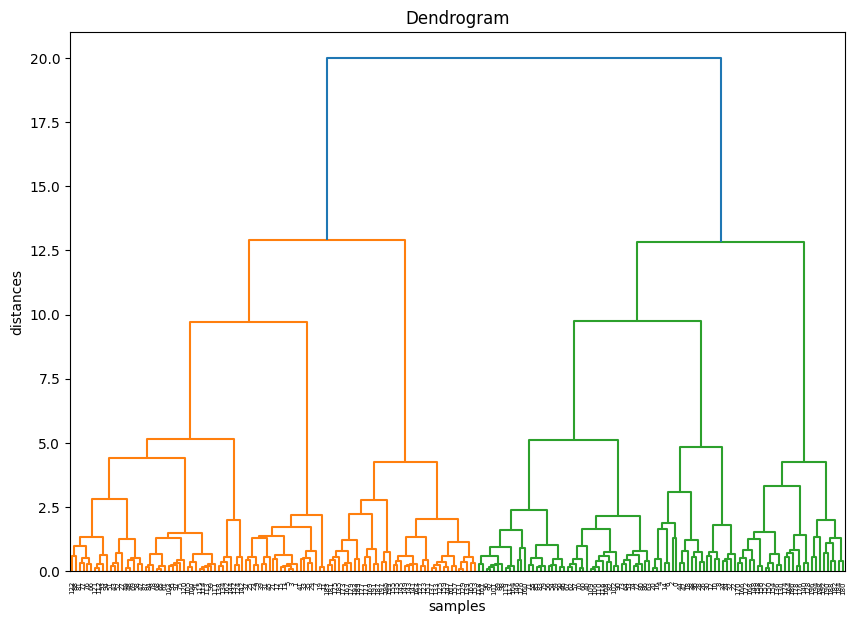

In [7]:
linked=linkage(scaled_data, method='ward')  #ward, complete, average, single for linkage method

plt.figure(figsize=(10,7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('samples')
plt.ylabel('distances')
plt.show()

### so for large datasets hirarchial clustering is not goot ,it good only for small datsets 

In [10]:
# train model
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=5)
model.fit(scaled_data)
labels = model.labels_
labels

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 1, 0, 4, 0,
       4, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 1, 2, 3, 2, 3, 2,
       0, 2, 0, 2, 3, 2, 0, 2, 3, 2, 0, 2, 0, 2, 1, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 1, 2, 0, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2])

In [26]:
#save the model
import joblib
joblib.dump(model, 'hierarchical_model_cluster.pkl')

['hierarchical_model_cluster.pkl']

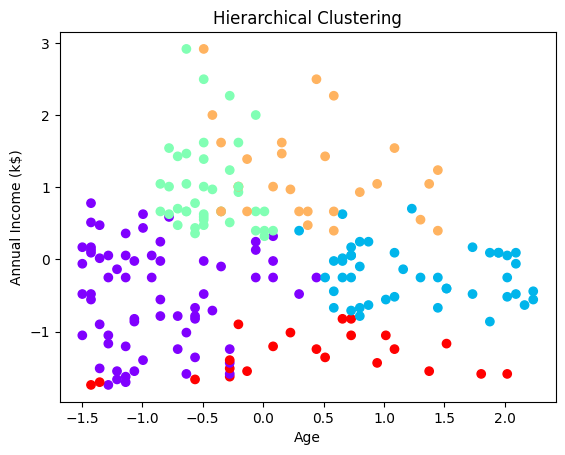

In [13]:
# visualization
plt.scatter(scaled_data.iloc[:, 0], scaled_data.iloc[:, 1], c=labels, cmap='rainbow')
plt.title('Hierarchical Clustering')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

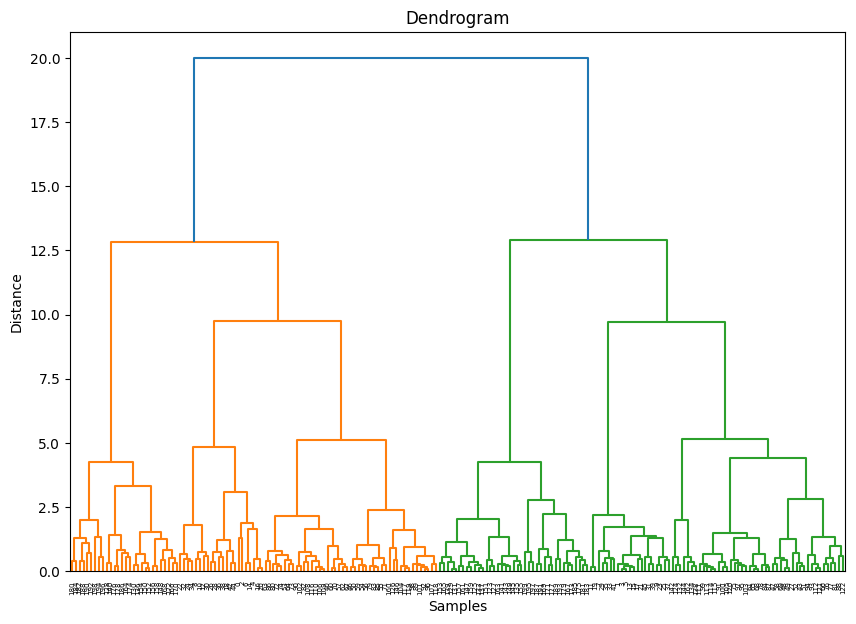

In [19]:
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.axhline(y=150, color='r', linestyle='--')
plt.title('Dendrogram' )
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [20]:
# train the model agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
agglomerative_clusters = model.fit_predict(scaled_data)
# display cluster labels
scaled_data['clusters' ] = agglomerative_clusters

In [21]:
print(scaled_data.head())

        Age  Annual Income (k$)  Spending Score (1-100)  clusters
0 -1.424569           -1.738999               -0.434801         4
1 -1.281035           -1.738999                1.195704         0
2 -1.352802           -1.700830               -1.715913         4
3 -1.137502           -1.700830                1.040418         0
4 -0.563369           -1.662660               -0.395980         4


In [22]:
# save the dataset
scaled_data.to_csv('hierarchical_clusters.csv', index=False)



In [24]:
# try supervised models
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
df1=pd.read_csv('hierarchical_clusters.csv')
X=df1.drop(columns=['clusters'])
y=df1['clusters']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))



0.925


In [25]:
#save the model
import joblib
joblib.dump(model, 'hierarchical_model.pkl')


['hierarchical_model.pkl']